In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/telco_clean.csv")
target = "Churn Value"
df.shape


(7043, 29)

In [3]:
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
leaky = ["Churn Label", "Churn Score", "Churn Reason", "CLTV"]
skip = ["CustomerID", "City", "Zip Code", "Latitude", "Longitude"]

categorical_cols = [c for c in df.columns
                    if c not in numeric_cols + leaky + skip + [target]]
print(len(categorical_cols))
print(categorical_cols)

16
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [4]:
df.groupby("Churn Label")[numeric_cols].agg(["mean", "median"]).round(1)

Tenure Months        Monthly Charges        Total Charges        
                     mean median            mean median          mean  median
Churn Label                                                                  
No                   37.6   38.0            61.3   64.4        2549.9  1679.5
Yes                  18.0   10.0            74.4   79.6        1531.8   703.6

In [5]:
for col in ["Contract", "Payment Method", "Internet Service",
            "Tech Support", "Paperless Billing", "Senior Citizen",
            "Dependents", "Gender"]:
    summary = df.groupby(col)[target].agg(churn_rate="mean", customers="count")
    summary["churn_rate"] = (summary["churn_rate"] * 100).round(1)
    display(summary)

,churn_rate,customers
Contract,,
Month-to-month,42.7,3875
One year,11.3,1473
Two year,2.8,1695


,churn_rate,customers
Payment Method,,
Bank transfer (automatic),16.7,1544
Credit card (automatic),15.2,1522
Electronic check,45.3,2365
Mailed check,19.1,1612


,churn_rate,customers
Internet Service,,
DSL,19.0,2421
Fiber optic,41.9,3096
No,7.4,1526


,churn_rate,customers
Tech Support,,
No,41.6,3473
No internet service,7.4,1526
Yes,15.2,2044


,churn_rate,customers
Paperless Billing,,
No,16.3,2872
Yes,33.6,4171


,churn_rate,customers
Senior Citizen,,
No,23.6,5901
Yes,41.7,1142


,churn_rate,customers
Dependents,,
No,32.6,5416
Yes,6.5,1627


,churn_rate,customers
Gender,,
Female,26.9,3488
Male,26.2,3555


In [6]:
bins = [-1, 6, 12, 24, 48, 72]
labels = ["0-6", "7-12", "13-24", "25-48", "49-72"]
df["Tenure Bucket"] = pd.cut(df["Tenure Months"], bins=bins, labels=labels)

bucket = df.groupby("Tenure Bucket", observed=True)[target].agg(
    churn_rate="mean", customers="count", churners="sum")
bucket["churn_rate"] = (bucket["churn_rate"] * 100).round(1)
bucket

,churn_rate,customers,churners
Tenure Bucket,,,
0-6,52.9,1481,784
7-12,35.9,705,253
13-24,28.7,1024,294
25-48,20.4,1594,325
49-72,9.5,2239,213


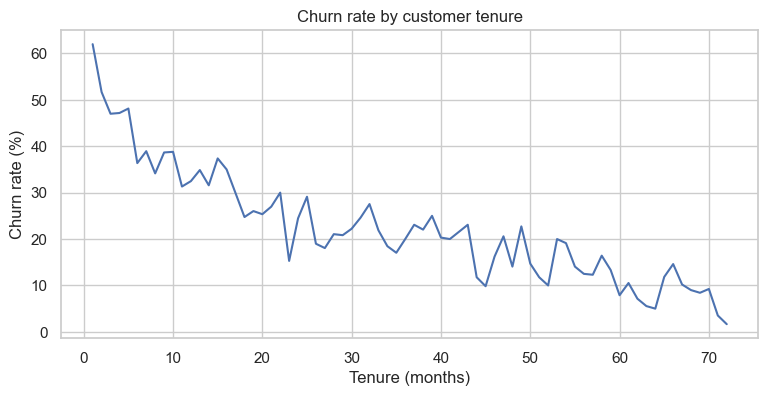

In [7]:
by_month = df[df["Tenure Months"] > 0].groupby("Tenure Months")[target].mean() * 100

plt.figure(figsize=(9, 4))
plt.plot(by_month.index, by_month.values)
plt.xlabel("Tenure (months)")
plt.ylabel("Churn rate (%)")
plt.title("Churn rate by customer tenure")
plt.savefig("../reports/tenure_cliff.png", dpi=150, bbox_inches="tight")
plt.show()

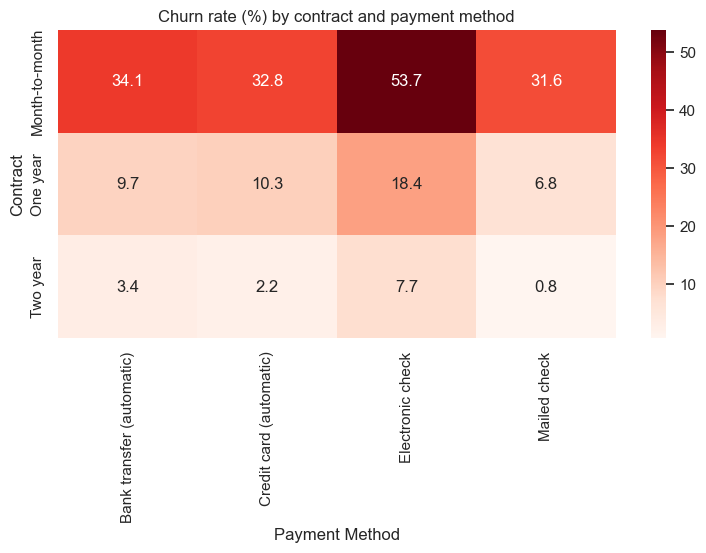

Customers: 1850
Churn rate: 53.7%
Share of ALL churners: 53.2%


In [8]:
pivot = df.pivot_table(index="Contract", columns="Payment Method",
                       values=target, aggfunc="mean") * 100

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn rate (%) by contract and payment method")
plt.savefig("../reports/contract_payment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

danger = df[(df["Contract"] == "Month-to-month") &
            (df["Payment Method"] == "Electronic check")]
print("Customers:", len(danger))
print(f"Churn rate: {danger[target].mean():.1%}")
print(f"Share of ALL churners: {danger[target].sum() / df[target].sum():.1%}")

In [9]:
net = df[df["Internet Service"] != "No"].copy()
protect = ["Online Security", "Online Backup", "Device Protection", "Tech Support"]
net["Protection Count"] = (net[protect] == "Yes").sum(axis=1)

summary = net.groupby("Protection Count")[target].agg(churn_rate="mean", customers="count")
summary["churn_rate"] = (summary["churn_rate"] * 100).round(1)
summary

,churn_rate,customers
Protection Count,,
0,56.7,1267
1,38.9,1467
2,23.8,1372
3,12.4,941
4,5.3,470


In [10]:
for col in numeric_cols:
    stayed = df.loc[df[target] == 0, col]
    left = df.loc[df[target] == 1, col]
    u, p = stats.mannwhitneyu(left, stayed)
    print(f"{col}: p-value = {p:.2e}")

Tenure Months: p-value = 2.42e-208
Monthly Charges: p-value = 3.31e-54
Total Charges: p-value = 5.69e-83


In [11]:
rows = []
for col in categorical_cols:
    table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    rows.append({"Feature": col, "p_value": p, "Cramers_V": round(v, 3)})

results = pd.DataFrame(rows).sort_values("Cramers_V", ascending=False)
results["Significant after Bonferroni"] = results["p_value"] < 0.05 / 19
results

,Feature,p_value,Cramers_V,Significant after Bonferroni
13,Contract,5.863038e-258,0.410,True
7,Online Security,2.661150e-185,0.347,True
10,Tech Support,1.443084e-180,0.343,True
6,Internet Service,9.571788e-160,0.322,True
15,Payment Method,3.682355e-140,0.303,True
8,Online Backup,2.079759e-131,0.292,True
9,Device Protection,5.505219e-122,0.282,True
3,Dependents,2.500972e-96,0.248,True
12,Streaming Movies,2.667757e-82,0.231,True
11,Streaming TV,5.528994e-82,0.231,True
